<a href="https://colab.research.google.com/github/braltoids0089/BIOMEDICINE/blob/main/MULTI%2BASSAY%2BINFERENCE%2BLAYER_for%2BmRNA_DESIGN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A Joint Multi-Assay Inference and Acquisition Layer for Closed-Loop mRNA Design


---

# A. Introduction and Background: A Thermodynamics-Constrained Differentiable Design for mRNA Therapeutics

The **"thermodynamics-constrained differentiable design" framework** provides a powerful, integrated solution for the complex, multi-objective challenges in mRNA therapeutic development. This framework might be helpful in addressing the needs within the **Australian Centre for RNA Therapeutics in Cancer (ACRTC)** at UWA, particularly across its two primary clinical frontiers: Pancreatic Cancer Microenvironment Targets and Non-Viral Delivery Vehicle & Nanoparticle Stability.

### 1. Pancreatic Cancer Microenvironment Targets

This frontier demands mRNA designs that can effectively function within a challenging biological environment and elicit precise immune responses. Our framework directly contributes by:

*   **Stroma-Resistant Sequences:** Utilizing differentiable thermodynamic descriptors (e.g., `duplex` content, `ensemble defect`) from `JAX-RNAfold`, the framework enables the design of sequences with optimized structural stability, directly enhancing mRNA persistence and resistance to degradation in dense, nuclease-rich pancreatic tumor microenvironments.
*   **Immune Reprogramming Kinetics & Viral Mimicry Profiles:** The framework integrates immune response (e.g., `log_imm` latent variable) and allows for fine-tuning mRNA sequence features to achieve a specific kinetic trajectory of cytokine expression. This is critical for achieving desired immune reprogramming without systemic toxicity, operating within a defined "feasible region" for immunogenicity.
*   **Ribosomal Competence:** By modeling `log_te` (translation rate) as a function of thermodynamic descriptors, the framework ensures that optimized structural stability does not compromise high-yield protein translation. It optimizes sequences to maintain ribosomal competence while satisfying other design objectives.

### 2. Non-Viral Delivery Vehicle & Nanoparticle Stability

This frontier focuses on the interaction between mRNA and its delivery vehicle, and its subsequent cellular journey. Our framework enhances this area through:

*   **Encapsulation Conformation:** The framework characterizes sequence-intrinsic thermodynamic properties that influence mRNA-nanoparticle interactions and packing, thus contributing to the overall durability and integrity of the mRNA cargo within its delivery vehicle.
*   **Serum Half-Life Tracking:** Through inference of `log_k` (decay rate) from DRS data, the framework enables direct tracking and optimization of mRNA half-life. Crucially, it employs hierarchical modeling to distinguish the mRNA sequence's intrinsic contribution from the significant effects of the LNP formulation, providing an accurate and actionable measure of durability.
*   **Cytoplasmic Release Efficiency:** Integrating fractionation data, the framework helps quantify the effective unpacking and release of intact mRNA into the target cell cytoplasm (`logit_rel`), which is fundamental for the mRNA to reach ribosomes and exert its therapeutic effect.

In essence, this framework provides the **integrated inference and decision layer** necessary to systematically navigate the complex interplay between mRNA sequence, its biophysical properties, delivery vehicle interactions, and ultimately, its therapeutic efficacy.

## B. Scope and Limitations

### B.1 In scope

Five of the eight ACRTC experimental/informatics parameters are core to this layer:

| # | Parameter | This layer | Owner |
|---|---|---|---|
| 1 | Stroma-resistant sequences | partial (sequence persistence only) | shared |
| 2 | Immune reprogramming kinetics | **core** | this work |
| 3 | Viral mimicry profiles | **core** | this work |
| 4 | Ribosomal competence | **core** | this work |
| 5 | Encapsulation conformation | no — consumed as covariate | Kretzmann |
| 6 | pH-responsive disassembly | no — consumed as covariate | Kretzmann |
| 7 | Serum half-life tracking | **core** (inference side) | shared |
| 8 | Cytoplasmic release efficiency | **core** (inference side) | shared |

### B.2 The central scientific claim

Objectives 2, 3 and 4 are **mutually antagonistic**, and none is a maximisation:

- raising structural stability increases duplex content → raises RIG-I/MDA5/PKR signalling (**3**)
  *and* impedes 43S scanning (**4**);
- immune reprogramming (**2**) requires a *specific kinetic trajectory* — cytokine biology punishes
  overshoot as hard as undershoot.

This is one **constrained multi-objective problem with an interior feasible region**, in which three
axes are coupled through a single physical object: the base-pair probability matrix. Duplex content,
ensemble defect and scanning accessibility are all differentiable functionals of the same partition
function, so gradients of the composite objective come from one backward pass.

Note the contrast with prior art: LinearDesign (Zhang *et al.*, **Nature** 2023) jointly optimises
MFE and codon usage, and reported that its best-performing molecules were **not** the lowest-MFE
ones — direct empirical support for a two-sided target rather than a stability maximiser.

### B.3 Out of scope — stated deliberately

- **Stromal penetration** is an LNP-scale property (size, PEG density, charge), not a sequence
  property. Claiming to design "stroma-resistant sequences" conflates length scales by two orders
  of magnitude.
- **Sequence generation** — supplied by JAX-RNAfold.
- **Encapsulation and disassembly chemistry** — supplied by the delivery capability.

### B.4 Limitations of this proof of concept

1. All wet-lab data are **simulated**. The simulator is separated from the inference code by a hard
   boundary; `joint_model` never sees ground truth.
2. `MockFoldingEngine` reproduces only the qualitative couplings (notably duplex ↔ scanning
   antagonism). `build_engine()` falls back to it when `jax_rnafold` is absent.
3. **Three rounds, one seed per arm.** Between-arm ordering in Section E is *indicative*, not
   established; a defensible version runs ≥20 seeds and reports bias distributions.
4. Innate-immune sensing is represented by a duplex proxy, not a mechanistic RIG-I/PKR model.
5. Chemistry determinants known to dominate durability — N1-methylpseudouridine, cap chemistry,
   poly(A) length — are **not** variables here.
6. Residual bias remains substantial (≈ +0.25 at n=36) even in the best arm. This is a genuine
   **power** finding, not a defect.


## C. Methodology & Foundations

### C.1 Why the assays cannot be averaged

| Assay | Measurand | Statistical character | Cost |
|---|---|---|---|
| DRS (RISER-enabled) | integrity over time | negative-binomial counts; **non-random** run-dependent selective sampling | 6 |
| eTCP-seq → STE | translation rate | **self-normalised** — identified only up to a per-run offset | 20 |
| Fractionation → FracFixR | fraction proportions | **compositional** — simplex + explicit unrecoverable fraction | 8 |
| IFN reporter | immunogenicity | Gaussian, direct | 1 |

Absolute DRS depth carries no information about abundance because RISER efficiency drifts run to
run; only the *shape across timepoints* identifies the decay rate. STE has no absolute scale on
which it could be aligned to DRS. Fractionation data live on a simplex. A joint latent-variable
model with **assay-specific likelihoods** is the only honest fusion.

### C.2 The formulation confound

The LNP performs most of the nuclease protection, so the sequence effect on half-life is a
second-order term atop a large carrier-dominated effect. Constructs are manufactured in formulation
batches, and batching correlates with design. Omit the formulation random effect and carrier
variance is misattributed to the sequence coefficient.

**This is the strongest single argument for one shared inference layer**: the delivery capability's
data is not adjacent to ours, it is a *nuisance parameter inside our model*.

### C.3 Model discrepancy

From round 3 a simulated process shift makes the thermodynamic model over-predict stability. A
hierarchical per-round discrepancy term (Kennedy & O'Hagan) absorbs it, rather than letting it
contaminate the sequence coefficients. Round 1 is pinned as the reference state; without that the
discrepancy terms are confounded with the intercept and the sampler wanders a flat ridge.

### C.4 Budgeted acquisition

Constructs are selected by posterior probability of landing in the feasible region, with an
uncertainty bonus and a diversity penalty. Assays are then allocated by a value-of-information
proxy — *decision sensitivity*, which peaks when the posterior straddles a constraint boundary and
vanishes when a construct is confidently inside or outside. Expensive eTCP-seq is purchased only
when translation is the binding uncertainty.

### C.5 Guarding against silent failure

Every bug encountered in development produced a **confident wrong answer**, never a crash:

| Failure | Presentation | Fix |
|---|---|---|
| Neal's funnel in `sd_k` | step size → 0, *zero-width* credible intervals, no divergences | non-centred parameterisation |
| float32 in Dirichlet-multinomial | log-gamma gradients lose all precision; chains freeze | `jax_enable_x64 = True` (**mandatory**) |
| `delta_round[0]` vs intercept | flat ridge, no mixing | pin round 1 as reference |
| ESS on `(draws, dim)` arrays | read as 400 chains × 4 draws → ESS 2792 vs true 377 | add leading chain axis |
| Between-group SS from grand mean | diagnostic printed 1.00 regardless of data | `Σ nₘ(x̄ₘ − x̄)²` |
| XLA cache growth across rounds | OOM-kill on the *final* fit, no traceback | `jax.clear_caches()` per fit |

`sampler_diagnostics()` therefore runs inside `fit()` and cannot be skipped.


## D. Model Modules and Implementation

Run the cells below in order. Section D.0 installs dependencies; D.1–D.8 define the modules.


### D.0 Environment and constants

`jax_enable_x64` is **required**, not a preference — see C.5.

In [ ]:
from __future__ import annotations

import json
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Protocol, Tuple

import numpy as np

import jax
import jax.numpy as jnp

!pip install numpyro
# (pip line stripped for script execution)
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

numpyro.set_host_device_count(1)
jax.config.update("jax_enable_x64", True)   # REQUIRED: the Dirichlet-multinomial
# log-gamma terms lose all gradient precision in float32 and NUTS silently freezes.

RNG = np.random.default_rng(20260819)

# ---------------------------------------------------------------------------
# Pharmacology / campaign constants
# ---------------------------------------------------------------------------

FEATURES = ("duplex", "ens_defect", "scan_access", "cai")
N_FEAT = len(FEATURES)

CYTOKINE_CLEARANCE = 0.30      # 1/h, first-order clearance of the expressed cytokine
TIME_GRID = np.linspace(0.0, 96.0, 193)   # h, for exposure integration
DRS_TIMEPOINTS = np.array([0.0, 6.0, 24.0, 48.0])
DRS_NOMINAL_READS = 2_500      # realistic per-construct depth after RISER enrichment
FRAC_TOTAL_COUNTS = 3_000
FRACTION_NAMES = ("cytosolic", "endosomal", "nuclear", "lost")

# Technical noise SDs are characterised from replicate controls, so they are
# treated as known. This removes a variance ridge and lets the construct-level
# terms (sd_te, sd_imm) be identified as *biological* variance.
STE_TECH_SD = 0.15
IFN_TECH_SD = 0.20

ASSAY_COST = {"drs": 6.0, "ste": 20.0, "frac": 8.0, "ifn": 1.0}
ROUND_BUDGET = 150.0
N_ROUNDS = 4
BATCH_SIZE = 8
DISCREPANCY_ONSET_ROUND = 3     # 1-indexed
DISCREPANCY_TRUE = 0.45         # added to log k: model over-predicts stability

N_FORMULATIONS = 4

# ---------------------------------------------------------------------------


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.8/394.8 kB 12.8 MB/s eta 0:00:00


### D.1 Folding engine — the JAX-RNAfold integration point

`build_engine()` prefers the real engine and falls back to the mock. The production docstring carries the actual `seq_pf` call signature; all four descriptors derive from one base-pair probability matrix.

In [ ]:
# 1. Folding engine -- the interface where JAX-RNAfold plugs in
# ---------------------------------------------------------------------------

class FoldingEngine(Protocol):
    """Maps a design vector to thermodynamic descriptors.

    PRODUCTION IMPLEMENTATION (JAX-RNAfold)
    ---------------------------------------
    All four descriptors are differentiable functionals of the base-pair
    probability matrix P produced by the generalised McCaskill recursion::

        from jax_rnafold.d2 import energy, seq_pf
        # p_seq : (L, 4) probabilistic sequence representation
        # bpp   : (L, L) expected base-pair probabilities
        duplex      = bpp.sum() / L                       # paired fraction
        ens_defect  = expected_defect(bpp, target_struct)  # ensemble defect
        scan_access = jnp.prod(1.0 - bpp[:LEADER].sum(1))  # 5' leader unpaired
        cai         = codon_adaptation(p_seq)             # differentiable CAI

    Because these share one partition function, gradients of the *composite*
    objective (durability / translation / immunogenicity) are obtained in a
    single backward pass. That is the entire reason to use differentiable
    folding rather than a black-box predictor.

    The mock below reproduces the qualitative couplings only -- in particular
    the structural antagonism between duplex content and 5' scanning access.
    """

    def descriptors(self, design: np.ndarray) -> np.ndarray:
        ...


class MockFoldingEngine:
    """Stand-in that preserves the couplings that matter for the demo."""

    name = "mock-fold (replace with JAX-RNAfold)"

    def __init__(self, seed: int = 7) -> None:
        self.rng = np.random.default_rng(seed)

    def sample_designs(self, n: int) -> np.ndarray:
        """Sample latent design knobs in [0, 1]^3 (structure, target, codon)."""
        return self.rng.uniform(0.0, 1.0, size=(n, 3))

    def descriptors(self, design: np.ndarray) -> np.ndarray:
        design = np.atleast_2d(design)
        s, t, c = design[:, 0], design[:, 1], design[:, 2]

        duplex = 0.35 + 0.50 * s + 0.02 * self.rng.normal(size=s.shape)
        # Structural antagonism: paired leader blocks 43S scanning.
        scan_access = 0.90 - 0.75 * s + 0.10 * t + 0.03 * self.rng.normal(size=s.shape)
        ens_defect = 0.05 + 0.40 * (1.0 - t) + 0.03 * self.rng.normal(size=s.shape)
        cai = 0.60 + 0.35 * c + 0.02 * self.rng.normal(size=s.shape)

        out = np.stack([duplex, ens_defect, scan_access, cai], axis=1)
        return np.clip(out, 0.01, 0.99)


def codon_adaptation(p_seq):
    """Differentiable CAI placeholder on probabilistic sequences (n, L, 4).

    INTEGRATION POINT: replace with a true codon-usage functional of p_seq.
    """
    return 0.60 + 0.35 * p_seq[..., 2].mean(axis=(1, 2))


class JAXRNAfoldEngine:
    """Production FoldingEngine backed by JAX-RNAfold (Krueger & Ward 2025).

    INTEGRATION POINTS (verify against the installed jax_rnafold version):
      * `seq_pf(p_seq)` returns the (L, L) base-pair probability matrix.
      * `codon_adaptation` is a differentiable CAI functional on (L, 4).
    If the package is missing, build_engine() falls back to MockFoldingEngine.
    """

    name = "JAX-RNAfold (differentiable partition function)"

    def __init__(self, length: int = 120, leader: int = 8,
                 target_bpp=None, seed: int = 7) -> None:
        import jax as _jax
        from jax_rnafold.d2 import seq_pf          # INTEGRATION POINT
        self._pf = _jax.vmap(seq_pf)                # batch over designs
        self._jax = _jax
        self.L, self.LEADER = length, leader
        self.target_bpp = target_bpp   # supply from Capability 2 when available
        self.rng = np.random.default_rng(seed)

    def sample_designs(self, n: int) -> np.ndarray:
        """Probabilistic sequences (n, L, 4); rows softmax-normalised."""
        logits = self.rng.normal(0.0, 1.0, size=(n, self.L, 4))
        e = np.exp(logits)
        return e / e.sum(-1, keepdims=True)

    def descriptors(self, design: np.ndarray) -> np.ndarray:
        jnp = self._jax.numpy
        bpp = self._pf(jnp.asarray(design))                     # (n, L, L)
        duplex = bpp.sum(axis=(1, 2)) / self.L
        scan_access = jnp.prod(1.0 - bpp[:, :self.LEADER].sum(-1), axis=-1)
        if self.target_bpp is not None:                         # INTEGRATION POINT
            ens_defect = jnp.abs(
                bpp - jnp.asarray(self.target_bpp)[None]).mean(axis=(1, 2))
        else:
            ens_defect = jnp.full_like(duplex, 0.25)  # neutral until Cap-2 target
        cai = codon_adaptation(jnp.asarray(design))
        out = jnp.stack([duplex, ens_defect, scan_access, cai], axis=1)
        return np.clip(np.asarray(out), 0.01, 0.99)


def build_engine(prefer: str = "mock-fold"):
    """Engine factory: try JAX-RNAfold, fall back to the mock."""
    if prefer == "jax-rnafold":
        try:
            return JAXRNAfoldEngine()
        except Exception as e:
            print(f"  [engine] jax_rnafold unavailable ({e}); falling back to mock.")
    return MockFoldingEngine()


# ---------------------------------------------------------------------------

### D.2 Ground truth simulator

**Inference never sees this.** Note the magnitudes: `sd_formulation_k = 0.50` is comparable to the entire span of the sequence effect — that is the point, not an exaggeration.

In [ ]:
# 2. Ground truth simulator  (INFERENCE NEVER SEES THIS)
# ---------------------------------------------------------------------------

@dataclass(frozen=True)
class TrueParams:
    """Generative truth. Note the magnitudes: the formulation SD on log-k is
    comparable to the entire span of the sequence effect. That is the point."""
    log_k0: float = -2.90                       # k ~ 0.055 /h  => t_1/2 ~ 12.6 h
    b_k: Tuple[float, ...] = (-1.20, 0.60, 0.0, 0.0)   # duplex protects; defect hurts
    sd_formulation_k: float = 0.50              # CARRIER-DOMINATED
    sd_k: float = 0.12

    log_te0: float = 0.0
    b_te: Tuple[float, ...] = (-1.00, -0.30, 1.50, 0.80)
    sd_te: float = 0.12

    log_imm0: float = 0.0
    b_imm: Tuple[float, ...] = (2.50, 0.0, 0.0, 0.0)   # duplex -> RIG-I/MDA5/PKR
    sd_imm: float = 0.15

    logit_rel_mu: float = 0.20                  # cytoplasmic release, per formulation
    logit_rel_sd: float = 0.55


TRUTH = TrueParams()
FEATURE_CENTER = np.array([0.60, 0.25, 0.50, 0.775])


def center(F: np.ndarray) -> np.ndarray:
    return np.atleast_2d(F) - FEATURE_CENTER


class GroundTruth:
    """Simulates latent construct biology and the four assays."""

    def __init__(self, seed: int = 11) -> None:
        self.rng = np.random.default_rng(seed)
        self.u_form = self.rng.normal(0.0, TRUTH.sd_formulation_k, size=N_FORMULATIONS)
        self.logit_rel = self.rng.normal(
            TRUTH.logit_rel_mu, TRUTH.logit_rel_sd, size=N_FORMULATIONS
        )
        self.release = 1.0 / (1.0 + np.exp(-self.logit_rel))

    # -- latents ------------------------------------------------------------
    def latents(self, F: np.ndarray, form_idx: np.ndarray, rnd: np.ndarray) -> Dict[str, np.ndarray]:
        Fc = center(F)
        disc = np.where(rnd >= DISCREPANCY_ONSET_ROUND, DISCREPANCY_TRUE, 0.0)
        log_k = (
            TRUTH.log_k0
            + Fc @ np.array(TRUTH.b_k)
            + self.u_form[form_idx]
            + disc
            + self.rng.normal(0.0, TRUTH.sd_k, size=len(F))
        )
        log_te = (
            TRUTH.log_te0
            + Fc @ np.array(TRUTH.b_te)
            + self.rng.normal(0.0, TRUTH.sd_te, size=len(F))
        )
        log_imm = (
            TRUTH.log_imm0
            + Fc @ np.array(TRUTH.b_imm)
            + self.rng.normal(0.0, TRUTH.sd_imm, size=len(F))
        )
        return {"log_k": log_k, "log_te": log_te, "log_imm": log_imm}

    # -- assay 1: DRS + RISER ----------------------------------------------
    def assay_drs(self, log_k: np.ndarray, run_id: int) -> Dict[str, np.ndarray]:
        """Negative-binomial counts under RISER selective sampling.

        RISER ejects non-target molecules from the pore in real time, so the
        sampling process is non-random *by design*. Its efficiency drifts run
        to run (eta_r), which means absolute depth carries no information about
        transcript abundance -- only the decay of counts across timepoints
        identifies k. Modelling this is not optional.
        """
        k = np.exp(log_k)
        eta = np.exp(self.rng.normal(0.0, 0.70))          # per-run RISER efficiency
        mean = DRS_NOMINAL_READS * eta * np.exp(-np.outer(k, DRS_TIMEPOINTS))
        phi = 8.0
        p = phi / (phi + mean)
        counts = self.rng.negative_binomial(phi, p)
        return {"counts": counts, "run": run_id}

    # -- assay 2: eTCP-seq -> STE ------------------------------------------
    def assay_ste(self, log_te: np.ndarray, run_id: int) -> Dict[str, np.ndarray]:
        """STE is self-normalised: comparable within a run, not across runs.

        We therefore observe log_te only up to an unknown additive offset s_r.
        There is no absolute scale on which STE can be aligned to DRS counts.
        """
        s_r = self.rng.normal(0.0, 0.30)
        obs = log_te + s_r + self.rng.normal(0.0, 0.15, size=len(log_te))
        return {"log_ste": obs, "run": run_id}

    # -- assay 3: fractionation -> FracFixR --------------------------------
    def assay_frac(self, form_idx: np.ndarray) -> Dict[str, np.ndarray]:
        """Compositional readout over {cytosolic, endosomal, nuclear, lost}.

        FracFixR's distinguishing feature is that it estimates the unrecoverable
        'lost' fraction rather than pretending the observed fractions sum to the
        whole. We mirror that with an explicit 4th component, and the data are
        simplex-constrained -- so they must be handled compositionally (ALR /
        Dirichlet-multinomial), never as independent proportions.
        """
        lr = self.logit_rel[form_idx]
        eta = np.stack(
            [lr, 0.30 - 0.80 * lr, np.full_like(lr, -1.0), np.full_like(lr, -0.50)],
            axis=1,
        )
        probs = np.exp(eta) / np.exp(eta).sum(axis=1, keepdims=True)
        counts = np.stack(
            [self.rng.multinomial(FRAC_TOTAL_COUNTS, p) for p in probs], axis=0
        )
        return {"counts": counts}

    # -- assay 4: IFN reporter ---------------------------------------------
    def assay_ifn(self, log_imm: np.ndarray) -> Dict[str, np.ndarray]:
        return {"log_ifn": log_imm + self.rng.normal(0.0, 0.20, size=len(log_imm))}




# ---------------------------------------------------------------------------

### D.3 Medical endpoint — cytokine exposure trajectory

One-compartment model giving AUC and peak. The feasible region is **two-sided on both exposure and immunogenicity**.

In [ ]:
# 3. The medical endpoint: cytokine exposure trajectory
# ---------------------------------------------------------------------------

def exposure_metrics(log_te, log_k, release, xp=jnp):
    """One-compartment cytokine model.

        dC/dt = te * release * exp(-k t)  -  kc * C

    Returns (AUC over 96 h, peak concentration). The therapeutic question is
    not 'how much protein' but 'does the exposure trajectory sit inside the
    window that reprograms the local immune environment without systemic
    toxicity' -- hence a two-sided AUC target AND a peak ceiling.
    """
    te = xp.exp(log_te)
    k = xp.exp(log_k)
    t = xp.asarray(TIME_GRID)
    kc = CYTOKINE_CLEARANCE

    k_ = k[..., None]
    denom = kc - k_
    denom = xp.where(xp.abs(denom) < 1e-3, 1e-3, denom)
    C = (te[..., None] * release[..., None] / denom) * (
        xp.exp(-k_ * t) - xp.exp(-kc * t)
    )
    C = xp.clip(C, 0.0, None)
    auc = xp.trapezoid(C, t, axis=-1)
    peak = C.max(axis=-1)
    return auc, peak


@dataclass(frozen=True)
class FeasibleRegion:
    """Interior target region -- two-sided on exposure AND immunogenicity."""
    auc_lo: float
    auc_hi: float
    peak_max: float
    imm_lo: float
    imm_hi: float
    te_min: float

    def describe(self) -> str:
        return (
            f"AUC in [{self.auc_lo:.1f}, {self.auc_hi:.1f}]  |  "
            f"peak <= {self.peak_max:.2f}  |  "
            f"log-IFN in [{self.imm_lo:.2f}, {self.imm_hi:.2f}]  |  "
            f"log-TE >= {self.te_min:.2f}"
        )


def calibrate_region(gt: GroundTruth, engine: MockFoldingEngine) -> FeasibleRegion:
    """Set the target region from quantiles of a large reference pool."""
    d = engine.sample_designs(4000)
    F = engine.descriptors(d)
    form = RNG.integers(0, N_FORMULATIONS, size=len(F))
    lat = gt.latents(F, form, np.ones(len(F), dtype=int))
    auc, peak = exposure_metrics(
        np.asarray(lat["log_te"]), np.asarray(lat["log_k"]), gt.release[form], xp=np
    )
    return FeasibleRegion(
        auc_lo=float(np.quantile(auc, 0.45)),
        auc_hi=float(np.quantile(auc, 0.80)),
        peak_max=float(np.quantile(peak, 0.80)),
        imm_lo=float(np.quantile(lat["log_imm"], 0.25)),
        imm_hi=float(np.quantile(lat["log_imm"], 0.65)),
        te_min=float(np.quantile(lat["log_te"], 0.30)),
    )



# ---------------------------------------------------------------------------

### D.4 Campaign state

Persists across rounds. An earlier version reset belief state at the start of every cycle, which silently defeated the entire closed-loop premise.

In [ ]:
# 4. Campaign state -- persists across rounds (the original POC reset it)
# ---------------------------------------------------------------------------

@dataclass
class CampaignState:
    features: List[np.ndarray] = field(default_factory=list)
    form_idx: List[int] = field(default_factory=list)
    round_idx: List[int] = field(default_factory=list)

    drs_cidx: List[int] = field(default_factory=list)
    drs_counts: List[np.ndarray] = field(default_factory=list)
    drs_run: List[int] = field(default_factory=list)

    ste_cidx: List[int] = field(default_factory=list)
    ste_val: List[float] = field(default_factory=list)
    ste_run: List[int] = field(default_factory=list)

    frac_cidx: List[int] = field(default_factory=list)
    frac_counts: List[np.ndarray] = field(default_factory=list)

    ifn_cidx: List[int] = field(default_factory=list)
    ifn_val: List[float] = field(default_factory=list)

    n_drs_runs: int = 0
    n_ste_runs: int = 0
    spend: float = 0.0

    @property
    def n_constructs(self) -> int:
        return len(self.features)

    def arrays(self) -> Dict[str, np.ndarray]:
        return {
            "F": np.array(self.features) if self.features else np.zeros((0, N_FEAT)),
            "form_idx": np.array(self.form_idx, dtype=int),
            "round_idx": np.array(self.round_idx, dtype=int),
            "drs_cidx": np.array(self.drs_cidx, dtype=int),
            "drs_counts": (np.array(self.drs_counts) if self.drs_counts
                           else np.zeros((0, len(DRS_TIMEPOINTS)))),
            "drs_run": np.array(self.drs_run, dtype=int),
            "ste_cidx": np.array(self.ste_cidx, dtype=int),
            "ste_val": np.array(self.ste_val),
            "ste_run": np.array(self.ste_run, dtype=int),
            "frac_cidx": np.array(self.frac_cidx, dtype=int),
            "frac_counts": (np.array(self.frac_counts) if self.frac_counts
                            else np.zeros((0, 4))),
            "ifn_cidx": np.array(self.ifn_cidx, dtype=int),
            "ifn_val": np.array(self.ifn_val),
        }



# ---------------------------------------------------------------------------

### D.5 The joint model

One latent state per construct; four assay-specific likelihoods. `log_te` and `log_imm` are conjugate and marginalised analytically — same posterior, ~3× cheaper. `log_k` is non-centred.

In [ ]:
# 5. The joint model
# ---------------------------------------------------------------------------

def joint_model(
    F,
    form_idx,
    round_idx,
    n_form,
    n_rounds,
    n_drs_runs,
    n_ste_runs,
    drs_cidx=None, drs_counts=None, drs_run=None,
    ste_cidx=None, ste_val=None, ste_run=None,
    frac_cidx=None, frac_counts=None,
    ifn_cidx=None, ifn_val=None,
    use_formulation_effect: bool = True,
    use_discrepancy: bool = True,
    carrier_prior: bool = False,
):
    """Hierarchical joint model over latent construct properties.

    One latent state per construct; four assay-specific likelihoods on top.
    Nuisance structure that MUST be modelled:
      * eta_r  -- RISER/DRS per-run efficiency (non-random sampling)
      * s_r    -- STE per-run offset (self-normalised measure)
      * u_b    -- formulation random effect on decay (carrier-dominated)
      * delta_r-- per-round model discrepancy (Kennedy & O'Hagan)
    """
    n = F.shape[0]
    Fc = F - jnp.asarray(FEATURE_CENTER)

    # --- decay: log k ------------------------------------------------------
    log_k0 = numpyro.sample("log_k0", dist.Normal(-3.0, 1.0))
    b_k = numpyro.sample("b_k", dist.Normal(0.0, 1.0).expand([N_FEAT]).to_event(1))

    if use_formulation_effect:
        if carrier_prior:
            # Characterised LNP replicate controls: informative carrier prior.
            sd_form = numpyro.sample(
                "sd_formulation_k", dist.TruncatedNormal(0.50, 0.15, low=0.0))
        else:
            sd_form = numpyro.sample("sd_formulation_k", dist.HalfNormal(0.8))
        u_raw = numpyro.sample(
            "u_form_raw", dist.Normal(0.0, 1.0).expand([n_form]).to_event(1)
        )
        u_form = numpyro.deterministic("u_form", u_raw * sd_form)
        form_term = u_form[form_idx]
    else:
        form_term = jnp.zeros(n)

    if use_discrepancy:
        # Round 1 is the reference process state (delta_1 == 0); otherwise the
        # discrepancy terms are confounded with the intercept and the sampler
        # wanders along a flat ridge.
        sd_disc = numpyro.sample("sd_discrepancy", dist.HalfNormal(0.5))
        d_raw = numpyro.sample(
            "delta_raw", dist.Normal(0.0, 1.0).expand([n_rounds - 1]).to_event(1)
        )
        delta = numpyro.deterministic(
            "delta_round", jnp.concatenate([jnp.zeros(1), d_raw * sd_disc])
        )
        disc_term = delta[round_idx]
    else:
        disc_term = jnp.zeros(n)

    # Non-centred: a centred parameterisation here produces Neal's funnel
    # between sd_k and the per-construct latents, and NUTS silently freezes
    # (step size -> 0, no divergences, no exploration).
    sd_k = numpyro.sample("sd_k", dist.LogNormal(np.log(0.15), 0.4))
    k_raw = numpyro.sample("log_k_raw", dist.Normal(0.0, 1.0).expand([n]).to_event(1))
    mu_k = log_k0 + Fc @ b_k + form_term + disc_term
    log_k = numpyro.deterministic("log_k", mu_k + sd_k * k_raw)

    # --- translation and immunogenicity -----------------------------------
    # Both have Gaussian priors and Gaussian likelihoods, so the per-construct
    # latents are conjugate and are marginalised analytically. This is not a
    # simplification of the science -- it is the same posterior, ~3x cheaper,
    # obtained by convolving the biological and technical variances.
    log_te0 = numpyro.sample("log_te0", dist.Normal(0.0, 1.0))
    b_te = numpyro.sample("b_te", dist.Normal(0.0, 1.5).expand([N_FEAT]).to_event(1))
    sd_te = numpyro.sample("sd_te", dist.HalfNormal(0.4))
    mu_te = log_te0 + Fc @ b_te

    log_imm0 = numpyro.sample("log_imm0", dist.Normal(0.0, 1.0))
    b_imm = numpyro.sample("b_imm", dist.Normal(0.0, 2.0).expand([N_FEAT]).to_event(1))
    sd_imm = numpyro.sample("sd_imm", dist.HalfNormal(0.4))
    mu_imm = log_imm0 + Fc @ b_imm

    # --- formulation release (identified by fractionation) -----------------
    mu_rel = numpyro.sample("logit_rel_mu", dist.Normal(0.0, 1.0))
    sd_rel = numpyro.sample("logit_rel_sd", dist.HalfNormal(1.0))
    r_raw = numpyro.sample(
        "logit_rel_raw", dist.Normal(0.0, 1.0).expand([n_form]).to_event(1)
    )
    logit_rel = numpyro.deterministic("logit_rel", mu_rel + r_raw * sd_rel)

    # ---------------- likelihoods -----------------------------------------
    # DRS: NB counts, per-run efficiency, non-random selective sampling
    if drs_counts is not None and drs_counts.shape[0] > 0:
        log_eta = numpyro.sample(
            "log_eta_drs", dist.Normal(0.0, 1.0).expand([n_drs_runs]).to_event(1)
        )
        phi = numpyro.sample("phi_drs", dist.HalfNormal(10.0))
        k_obs = jnp.exp(log_k[drs_cidx])
        mean = (
            DRS_NOMINAL_READS
            * jnp.exp(log_eta[drs_run])[:, None]
            * jnp.exp(-k_obs[:, None] * jnp.asarray(DRS_TIMEPOINTS)[None, :])
        )
        numpyro.sample(
            "obs_drs",
            dist.NegativeBinomial2(jnp.clip(mean, 1e-3, None), phi),
            obs=drs_counts,
        )

    # STE: self-normalised -> per-run offset, no absolute scale
    if ste_val is not None and ste_val.shape[0] > 0:
        s_run = numpyro.sample(
            "s_ste", dist.Normal(0.0, 0.3).expand([n_ste_runs]).to_event(1)
        )
        sig = jnp.sqrt(sd_te ** 2 + STE_TECH_SD ** 2)
        numpyro.sample(
            "obs_ste",
            dist.Normal(mu_te[ste_cidx] + s_run[ste_run], sig),
            obs=ste_val,
        )

    # Fractionation: compositional, Dirichlet-multinomial with a 'lost' component
    if frac_counts is not None and frac_counts.shape[0] > 0:
        conc = numpyro.sample("frac_conc", dist.HalfNormal(500.0))
        lr = logit_rel[form_idx][frac_cidx]
        eta_f = jnp.stack(
            [lr, 0.30 - 0.80 * lr, jnp.full_like(lr, -1.0), jnp.full_like(lr, -0.5)],
            axis=1,
        )
        probs = jax.nn.softmax(eta_f, axis=1)
        numpyro.sample(
            "obs_frac",
            dist.DirichletMultinomial(
                concentration=jnp.clip(conc, 1.0, None) * probs + 1e-3,
                total_count=FRAC_TOTAL_COUNTS,
            ),
            obs=frac_counts,
        )

    # IFN reporter: cheap, direct
    if ifn_val is not None and ifn_val.shape[0] > 0:
        sig_i = jnp.sqrt(sd_imm ** 2 + IFN_TECH_SD ** 2)
        numpyro.sample("obs_ifn", dist.Normal(mu_imm[ifn_cidx], sig_i), obs=ifn_val)


def sampler_diagnostics(by_chain, divergences,
                        watch=("b_k", "log_k", "delta_round", "sd_k")):
    """Confident-wrong guards: dead-sampler / mixing checks.

    Every failure mode internalised so far produced a *confident wrong*
    answer, not a crash (frozen NUTS with zero-width CIs, float32 gradient
    freeze, discrepancy-intercept ridge). These checks make the fourth
    bug class impossible to miss.
    """
    from numpyro.diagnostics import effective_sample_size, split_gelman_rubin
    diag = {"divergences": int(divergences), "warnings": []}
    for name in watch:
        if name not in by_chain:
            continue
        xc = np.asarray(by_chain[name])            # (chains, draws, ...)
        n_draw = xc.shape[0] * xc.shape[1]
        sd = float(np.std(xc.reshape(n_draw, -1), axis=0).max())
        ess = float(np.min(effective_sample_size(xc)))
        rhat = float(np.max(split_gelman_rubin(xc)))
        if sd < 1e-6:
            diag["warnings"].append(f"{name}: ZERO-WIDTH posterior -> dead sampler")
        if ess < 0.10 * n_draw:
            diag["warnings"].append(f"{name}: ESS {ess:.0f} < 10% of {n_draw} draws")
        if rhat > 1.05:
            diag["warnings"].append(f"{name}: Rhat {rhat:.2f} > 1.05")
    for w in diag["warnings"]:
        print(f"  [sampler]     WARNING: {w}")
    return diag


def fit(state, *, use_formulation_effect=True, use_discrepancy=True,
        carrier_prior=False, warmup=200, samples=200, seed=0):
    a = state.arrays()
    # Each round changes data shapes, so XLA compiles a fresh executable and
    # caches it. Across a multi-round campaign the cache grows until the
    # process is OOM-killed mid-fit -- silently, with no traceback.
    jax.clear_caches()
    kernel = NUTS(joint_model, target_accept_prob=0.95)
    # 4 chains, vmapped onto one device. With num_chains=1 the split-Rhat check
    # can only see non-stationarity within a single chain -- it cannot detect
    # multimodality or between-chain disagreement, which is most of what Rhat
    # is for. Vectorised chains cost far less than 4x wall time.
    mcmc = MCMC(kernel, num_warmup=warmup, num_samples=samples,
                num_chains=2, chain_method="vectorized", progress_bar=False)
    mcmc.run(
        jax.random.PRNGKey(seed),
        F=jnp.asarray(a["F"]),
        form_idx=jnp.asarray(a["form_idx"]),
        round_idx=jnp.asarray(a["round_idx"] - 1),
        n_form=N_FORMULATIONS,
        n_rounds=N_ROUNDS,
        n_drs_runs=max(state.n_drs_runs, 1),
        n_ste_runs=max(state.n_ste_runs, 1),
        drs_cidx=jnp.asarray(a["drs_cidx"]),
        drs_counts=jnp.asarray(a["drs_counts"]),
        drs_run=jnp.asarray(a["drs_run"]),
        ste_cidx=jnp.asarray(a["ste_cidx"]),
        ste_val=jnp.asarray(a["ste_val"]),
        ste_run=jnp.asarray(a["ste_run"]),
        frac_cidx=jnp.asarray(a["frac_cidx"]),
        frac_counts=jnp.asarray(a["frac_counts"]),
        ifn_cidx=jnp.asarray(a["ifn_cidx"]),
        ifn_val=jnp.asarray(a["ifn_val"]),
        use_formulation_effect=use_formulation_effect,
        use_discrepancy=use_discrepancy,
        carrier_prior=carrier_prior,
        extra_fields=("diverging",),
    )
    div = int(np.asarray(mcmc.get_extra_fields()["diverging"]).sum())
    if div > 0:
        print(f"  [sampler]     WARNING: {div}/{samples} divergent transitions")
    out = {k: np.asarray(v) for k, v in mcmc.get_samples().items()}
    out["_divergences"] = np.array([div])
    by_chain = {k: np.asarray(v) for k, v in
                mcmc.get_samples(group_by_chain=True).items()}
    out["_diag"] = sampler_diagnostics(by_chain, div)   # confident-wrong guard
    return out


# ---------------------------------------------------------------------------

### D.6 Prediction and budgeted acquisition

Decision-sensitivity VOI proxy under a fixed per-round budget.

In [ ]:
# 6. Prediction and acquisition
# ---------------------------------------------------------------------------

def predict_candidates(post: Dict[str, np.ndarray], Fcand: np.ndarray,
                       form: int, current_round: int, n_draw: int = 400):
    """Posterior predictive over candidate designs in a chosen formulation."""
    S = len(post["log_k0"])
    idx = RNG.choice(S, size=min(n_draw, S), replace=False)
    Fc = center(Fcand)

    lk = post["log_k0"][idx][:, None] + post["b_k"][idx] @ Fc.T
    if "u_form" in post:
        lk = lk + post["u_form"][idx][:, form][:, None]
    if "delta_round" in post:
        lk = lk + post["delta_round"][idx][:, current_round - 1][:, None]
    lk = lk + RNG.normal(0, 1, lk.shape) * post["sd_k"][idx][:, None]

    lte = post["log_te0"][idx][:, None] + post["b_te"][idx] @ Fc.T
    lte = lte + RNG.normal(0, 1, lte.shape) * post["sd_te"][idx][:, None]

    lim = post["log_imm0"][idx][:, None] + post["b_imm"][idx] @ Fc.T
    lim = lim + RNG.normal(0, 1, lim.shape) * post["sd_imm"][idx][:, None]

    rel = 1.0 / (1.0 + np.exp(-post["logit_rel"][idx][:, form]))[:, None]
    rel = np.broadcast_to(rel, lk.shape)

    auc, peak = exposure_metrics(lte, lk, rel, xp=np)
    return {"log_k": lk, "log_te": lte, "log_imm": lim, "auc": auc, "peak": peak}


def p_feasible(pred: Dict[str, np.ndarray], reg: FeasibleRegion) -> np.ndarray:
    ok = (
        (pred["auc"] >= reg.auc_lo) & (pred["auc"] <= reg.auc_hi)
        & (pred["peak"] <= reg.peak_max)
        & (pred["log_imm"] >= reg.imm_lo) & (pred["log_imm"] <= reg.imm_hi)
        & (pred["log_te"] >= reg.te_min)
    )
    return ok.mean(axis=0)


def select_batch(Fcand, pred, reg, k=BATCH_SIZE, explore=0.35):
    """Greedy batch: probability of feasibility + uncertainty bonus + diversity."""
    pf = p_feasible(pred, reg)
    unc = pred["auc"].std(axis=0) / (np.abs(pred["auc"].mean(axis=0)) + 1e-6)
    score = pf + explore * np.clip(unc, 0, 1.5)

    chosen: List[int] = []
    Fn = (Fcand - Fcand.mean(0)) / (Fcand.std(0) + 1e-9)
    for _ in range(k):
        s = score.copy()
        if chosen:
            d = np.linalg.norm(Fn[:, None, :] - Fn[None, chosen, :], axis=-1).min(1)
            s = s * (1.0 - np.exp(-1.2 * d))
        s[chosen] = -np.inf
        chosen.append(int(np.argmax(s)))
    return np.array(chosen), pf


def allocate_assays(pred, chosen, reg, budget=ROUND_BUDGET) -> Dict[int, List[str]]:
    """Value-of-information proxy: buy the assay that most reduces uncertainty
    on the *binding* constraint, per unit cost.

    This is the honest version of 'situationally intelligent activation'. The
    expensive eTCP-seq/STE run (cost 20) is only purchased when translation is
    what stands between us and a decision -- not on a fixed schedule.
    """
    alloc = {int(c): [] for c in chosen}
    spend = 0.0

    def sensitivity(mean, sd, bounds):
        """Decision sensitivity: how much a constraint's satisfaction could
        still flip. Peaks when the posterior straddles a boundary, and is
        near zero when the construct is confidently inside or outside.
        """
        sd = max(float(sd), 1e-6)
        z = min(abs(float(mean) - b) / sd for b in bounds)
        return sd * float(np.exp(-0.5 * z * z))

    def value(c_local, assay):
        if assay == "drs":
            return sensitivity(pred["auc"][:, c_local].mean(),
                               pred["auc"][:, c_local].std(),
                               [reg.auc_lo, reg.auc_hi]) / 10.0
        if assay == "ste":
            return sensitivity(pred["log_te"][:, c_local].mean(),
                               pred["log_te"][:, c_local].std(), [reg.te_min])
        if assay == "ifn":
            return sensitivity(pred["log_imm"][:, c_local].mean(),
                               pred["log_imm"][:, c_local].std(),
                               [reg.imm_lo, reg.imm_hi])
        if assay == "frac":
            return 0.30 * pred["auc"][:, c_local].std() / (
                abs(pred["auc"][:, c_local].mean()) + 1e-6)
        return 0.0

    options = []
    for local, c in enumerate(chosen):
        for assay in ASSAY_COST:
            options.append((value(local, assay) / ASSAY_COST[assay], assay, int(c)))
    options.sort(reverse=True)

    for _, assay, c in options:
        if spend + ASSAY_COST[assay] > budget:
            continue
        if assay in alloc[c]:
            continue
        alloc[c].append(assay)
        spend += ASSAY_COST[assay]
    return alloc



# ---------------------------------------------------------------------------

### D.7 Campaign driver

Includes the duplex-stratified seed, the crossed carrier-control block, and the per-round confounding diagnostic.

In [ ]:
# 7. Campaign driver
# ---------------------------------------------------------------------------

def assign_formulation(F: np.ndarray, rnd: int, randomize: bool = False) -> np.ndarray:
    """Constructs are manufactured in formulation batches, and batching is
    correlated with design (high-duplex constructs tend to be made together).
    This is exactly the confounding that biases a naive sequence-effect model.
    randomize=True gives the de-confounded arm (revision).
    """
    if randomize:
        return RNG.integers(0, N_FORMULATIONS, len(F)).astype(int)
    duplex = F[:, 0]
    q = np.searchsorted(np.quantile(duplex, [0.34, 0.67]), duplex)
    jitter = RNG.random(len(F)) < 0.2
    q = np.where(jitter, RNG.integers(0, N_FORMULATIONS, len(F)), q)
    return np.clip(q, 0, N_FORMULATIONS - 1).astype(int)


def seed_batch(Fcand: np.ndarray, n_strata: int = 4, per_stratum: int = 2) -> np.ndarray:
    """Duplex-stratified seed: 2 constructs per duplex quartile.

    V2 stratified by FORMULATION and took duplex extremes within each batch.
    That cannot work when formulation is assigned *from* duplex -- you cannot
    decorrelate two variables when one is a deterministic function of the
    other. It made things worse: it shrank the within-batch duplex range and
    the b_k[duplex] bias went from +0.14 (V1) to +1.08.

    Confounding is a property of the DESIGN, not of the selection rule.
    The fix lives in assign_formulation(randomize=True) and in the crossed
    carrier-control block -- not here. This seed does the one thing a seed
    honestly can: span the covariate range evenly.
    """
    dup = Fcand[:, 0]
    edges = np.quantile(dup, np.linspace(0, 1, n_strata + 1))
    chosen: List[int] = []
    for i in range(n_strata):
        lo, hi = edges[i], edges[i + 1]
        pool = np.where((dup >= lo) & (dup <= hi))[0]
        pool = np.array([p for p in pool if p not in chosen])
        if len(pool) == 0:
            continue
        chosen += list(RNG.choice(pool, size=min(per_stratum, len(pool)),
                                  replace=False))
    return np.array(chosen[: n_strata * per_stratum])


def carrier_control_block(engine, gt, state, n_ctrl: int = 3):
    """Crossed carrier-characterisation block (replaces the hardcoded prior).

    V2 identified carrier variance with TruncatedNormal(0.50, 0.15) centred
    on the simulator's true sd_formulation_k = 0.50. In a simulation study
    that is circular: it narrows b_k[duplex] by telling the model the answer.

    The honest version spends budget. A few reference constructs are run in
    EVERY formulation, so the carrier effects u_b are identified directly by
    a crossed design rather than asserted by a prior. This is also what the
    lab would actually do.

    Cost: n_ctrl * N_FORMULATIONS DRS runs.
    """
    d = engine.sample_designs(n_ctrl)
    Fc = engine.descriptors(d)
    F_rep = np.repeat(Fc, N_FORMULATIONS, axis=0)
    form = np.tile(np.arange(N_FORMULATIONS), n_ctrl)
    lat = gt.latents(F_rep, form, np.ones(len(F_rep), dtype=int))

    base = state.n_constructs
    for j in range(len(F_rep)):
        state.features.append(F_rep[j])
        state.form_idx.append(int(form[j]))
        state.round_idx.append(1)

    run = state.n_drs_runs
    state.n_drs_runs += 1
    out = gt.assay_drs(lat["log_k"], run)
    for m, row in enumerate(out["counts"]):
        state.drs_cidx.append(base + m)
        state.drs_counts.append(row)
        state.drs_run.append(run)
    cost = ASSAY_COST["drs"] * len(F_rep)
    state.spend += cost
    print(f"  [controls]    crossed carrier block: {n_ctrl} constructs x "
          f"{N_FORMULATIONS} formulations = {len(F_rep)} DRS  (cost {cost:.0f})")
    return cost


def run_campaign(randomize_formulation: bool = False,
                 carrier_prior: bool = False,
                 carrier_controls: bool = False,
                 label: str = "arm",
                 prefer_engine: str = "mock-fold"):
    engine = build_engine(prefer_engine)
    gt = GroundTruth()
    reg = calibrate_region(gt, engine)

    print("=" * 78)
    print("ACRTC JOINT MULTI-ASSAY INFERENCE LAYER  --  simulated campaign (V2)")
    print("=" * 78)
    print(f"Folding engine     : {engine.name}")
    print(f"Feasible region    : {reg.describe()}")
    print(f"Budget per round   : {ROUND_BUDGET:.0f} cost units   "
          f"(drs {ASSAY_COST['drs']:.0f} / ste {ASSAY_COST['ste']:.0f} / "
          f"frac {ASSAY_COST['frac']:.0f} / ifn {ASSAY_COST['ifn']:.0f})")
    print(f"Process shift      : +{DISCREPANCY_TRUE} on log k from round "
          f"{DISCREPANCY_ONSET_ROUND} (thermodynamic model over-predicts stability)")
    print(f"Design arms        : randomize_formulation={randomize_formulation} "
          f"carrier_prior={carrier_prior} carrier_controls={carrier_controls} "
          f"[{label}]")
    print()

    state = CampaignState()
    if carrier_controls:
        carrier_control_block(engine, gt, state)
    post: Optional[Dict[str, np.ndarray]] = None
    history = []

    for rnd in range(1, N_ROUNDS + 1):
        print("-" * 78)
        print(f"ROUND {rnd}")
        print("-" * 78)

        # ---- propose ------------------------------------------------------
        cand_designs = engine.sample_designs(300)
        Fcand = engine.descriptors(cand_designs)

        if post is None:
            sel = seed_batch(Fcand)
            pf_sel = np.full(BATCH_SIZE, np.nan)
            alloc = {int(c): ["drs", "ifn"] for c in sel}
            for c in sel[:3]:
                alloc[int(c)].append("frac")
            for c in sel[:2]:
                alloc[int(c)].append("ste")
            print("  [acquisition] stratified extremal-duplex seed batch (revision)")
        else:
            pred = predict_candidates(post, Fcand, form=0, current_round=rnd)
            sel, pf_all = select_batch(Fcand, pred, reg)
            pf_sel = pf_all[sel]
            local = {int(c): i for i, c in enumerate(sel)}
            predsub = {kk: vv[:, sel] for kk, vv in pred.items()}
            alloc = allocate_assays(predsub, sel, reg)
            print(f"  [acquisition] pool P(feasible): max={pf_all.max():.3f} "
                  f"mean={pf_all.mean():.3f}")
            print(f"  [acquisition] selected batch P(feasible)="
                  f"{np.round(pf_sel, 3).tolist()}")

        F_new = Fcand[sel]
        form_new = assign_formulation(F_new, rnd, randomize=randomize_formulation)
        base = state.n_constructs

        # Design-confounding diagnostic (revision): how collinear is this
        # realised batch with the formulation blocks?
        d = F_new[:, 0]
        sst = float(np.sum((d - d.mean()) ** 2)) if len(d) > 1 else 1.0
        ssb = float(sum(len(d[form_new == g]) * (d[form_new == g].mean() - d.mean()) ** 2
                        for g in range(N_FORMULATIONS)
                        if (form_new == g).sum() > 0)) if len(d) > 1 else 0.0
        print(f"  [design]      duplex variance explained by formulation "
              f"batch: {ssb / sst:.2f}")

        lat = gt.latents(F_new, form_new, np.full(len(F_new), rnd))

        for j in range(len(F_new)):
            state.features.append(F_new[j])
            state.form_idx.append(int(form_new[j]))
            state.round_idx.append(rnd)

        # ---- execute assays ----------------------------------------------
        spent = 0.0
        drs_members = [j for j, c in enumerate(sel) if "drs" in alloc[int(c)]]
        ste_members = [j for j, c in enumerate(sel) if "ste" in alloc[int(c)]]
        frac_members = [j for j, c in enumerate(sel) if "frac" in alloc[int(c)]]
        ifn_members = [j for j, c in enumerate(sel) if "ifn" in alloc[int(c)]]

        if drs_members:
            run = state.n_drs_runs
            state.n_drs_runs += 1
            out = gt.assay_drs(lat["log_k"][drs_members], run)
            for m, row in zip(drs_members, out["counts"]):
                state.drs_cidx.append(base + m)
                state.drs_counts.append(row)
                state.drs_run.append(run)
            spent += ASSAY_COST["drs"] * len(drs_members)

        if ste_members:
            run = state.n_ste_runs
            state.n_ste_runs += 1
            out = gt.assay_ste(lat["log_te"][ste_members], run)
            for m, v in zip(ste_members, out["log_ste"]):
                state.ste_cidx.append(base + m)
                state.ste_val.append(float(v))
                state.ste_run.append(run)
            spent += ASSAY_COST["ste"] * len(ste_members)

        if frac_members:
            out = gt.assay_frac(form_new[frac_members])
            for m, row in zip(frac_members, out["counts"]):
                state.frac_cidx.append(base + m)
                state.frac_counts.append(row)
            spent += ASSAY_COST["frac"] * len(frac_members)

        if ifn_members:
            out = gt.assay_ifn(lat["log_imm"][ifn_members])
            for m, v in zip(ifn_members, out["log_ifn"]):
                state.ifn_cidx.append(base + m)
                state.ifn_val.append(float(v))
            spent += ASSAY_COST["ifn"] * len(ifn_members)

        state.spend += spent
        print(f"  [assays]      drs={len(drs_members)} ste={len(ste_members)} "
              f"frac={len(frac_members)} ifn={len(ifn_members)}  "
              f"spend={spent:.0f}  cumulative={state.spend:.0f}")

        # ---- infer --------------------------------------------------------
        post = fit(state, seed=rnd, carrier_prior=carrier_prior)

        bk_d = post["b_k"][:, 0]
        dr = post["delta_round"][:, rnd - 1]
        auc_sd = None
        if "log_k" in post:
            auc_sd = float(post["log_k"].std(axis=0).mean())

        # Honest learning curves (revision): fixed seed cohort + coefficient
        # SD, not the cohort-mixed mean SD (which conflates learning with
        # cohort turnover).
        fixed_sd = float(post["log_k"][:, :BATCH_SIZE].std(axis=0).mean())
        bk_sd = float(post["b_k"][:, 0].std())

        print(f"  [posterior]   b_k[duplex]   = {bk_d.mean():+.3f} "
              f"[{np.quantile(bk_d,0.05):+.3f}, {np.quantile(bk_d,0.95):+.3f}]  "
              f"(truth {TRUTH.b_k[0]:+.2f})")
        print(f"  [posterior]   delta_round{rnd}  = {dr.mean():+.3f} "
              f"[{np.quantile(dr,0.05):+.3f}, {np.quantile(dr,0.95):+.3f}]  "
              f"(truth {DISCREPANCY_TRUE if rnd>=DISCREPANCY_ONSET_ROUND else 0.0:+.2f})")
        print(f"  [posterior]   mean SD(log k per construct) = {auc_sd:.3f}")
        print(f"  [posterior]   fixed-cohort SD(log k) = {fixed_sd:.3f} | "
              f"SD(b_k[duplex]) = {bk_sd:.3f}")

        history.append({
            "round": rnd,
            "n_constructs": state.n_constructs,
            "spend": state.spend,
            "b_k_duplex_mean": float(bk_d.mean()),
            "b_k_duplex_lo": float(np.quantile(bk_d, 0.05)),
            "b_k_duplex_hi": float(np.quantile(bk_d, 0.95)),
            "delta_mean": float(dr.mean()),
            "delta_lo": float(np.quantile(dr, 0.05)),
            "delta_hi": float(np.quantile(dr, 0.95)),
            "mean_sd_log_k": auc_sd,
            "fixed_cohort_sd_log_k": fixed_sd,
            "bk_duplex_sd": bk_sd,
            "batch_p_feasible": [float(x) for x in np.atleast_1d(pf_sel)],
        })

    # ---- naive comparison (no formulation random effect) ------------------
    print()
    print("=" * 78)
    print("CONFOUNDING CHECK: omit the formulation random effect")
    print("=" * 78)
    post_naive = fit(state, use_formulation_effect=False, seed=99,
                     carrier_prior=carrier_prior)
    bn = post_naive["b_k"][:, 0]
    bh = post["b_k"][:, 0]
    print(f"  truth                b_k[duplex] = {TRUTH.b_k[0]:+.3f}")
    print(f"  hierarchical (u_b)   b_k[duplex] = {bh.mean():+.3f} "
          f"[{np.quantile(bh,0.05):+.3f}, {np.quantile(bh,0.95):+.3f}]")
    print(f"  naive (no u_b)       b_k[duplex] = {bn.mean():+.3f} "
          f"[{np.quantile(bn,0.05):+.3f}, {np.quantile(bn,0.95):+.3f}]")
    print(f"  bias (naive - truth) = {bn.mean() - TRUTH.b_k[0]:+.3f}   "
          f"|  hierarchical bias = {bh.mean() - TRUTH.b_k[0]:+.3f}")
    print()
    print("  Interpretation: constructs are batched by formulation, and the")
    print("  carrier contributes more variance to half-life than the sequence")
    print("  does. Without partial pooling on formulation, carrier variance is")
    print("  misattributed to the duplex coefficient -- i.e. the delivery")
    print("  capability's data is not adjacent to ours, it is a nuisance")
    print("  parameter inside our model.")

    return state, post, post_naive, history, reg, gt, engine


# ---------------------------------------------------------------------------

### D.8 Figure and self-contained report

In [ ]:
# 8. Figure + self-contained report
# ---------------------------------------------------------------------------

def make_figure(history, post, post_naive, reg, gt, engine, path=None, show=False):
    import matplotlib
    if not show:
        matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    import os

    fig, ax = plt.subplots(2, 2, figsize=(12.5, 9.0))
    rounds = [h["round"] for h in history]

    # (a) honest learning curves (revision): fixed seed cohort + coefficient
    # SD; the old cohort-mixed mean SD is kept only as a fallback.
    a = ax[0, 0]
    if "fixed_cohort_sd_log_k" in history[0]:
        a.plot(rounds, [h["fixed_cohort_sd_log_k"] for h in history], "o-",
               color="#2a7fbf", label="fixed seed cohort: SD(log k)")
        a.plot(rounds, [h["bk_duplex_sd"] for h in history], "s-",
               color="#e9c46a", label="SD(b_k[duplex])")
        a.legend(fontsize=8)
    else:
        a.plot(rounds, [h["mean_sd_log_k"] for h in history], "o-", color="#2a7fbf")
    a.set_xlabel("round"); a.set_ylabel("posterior SD")
    a.set_title("(a) Honest learning curves: fixed cohort and\n"
                "coefficient uncertainty (state persists)", fontsize=10)
    a.set_xticks(rounds); a.grid(alpha=0.3)

    # (b) confounding bias
    b = ax[0, 1]
    bn, bh = post_naive["b_k"][:, 0], post["b_k"][:, 0]
    b.hist(bn, bins=50, alpha=0.6, density=True, label="naive (no formulation effect)",
           color="#d1495b")
    b.hist(bh, bins=50, alpha=0.6, density=True, label="hierarchical (partial pooling)",
           color="#2a7fbf")
    b.axvline(TRUTH.b_k[0], color="k", ls="--", lw=2, label="truth")
    b.set_xlabel("b_k[duplex]  (sequence effect on decay)")
    b.set_ylabel("posterior density")
    b.set_title("(b) Omitting formulation misattributes carrier\n"
                "variance to the sequence coefficient", fontsize=10)
    b.legend(fontsize=8); b.grid(alpha=0.3)

    # (c) discrepancy detection
    c = ax[1, 0]
    m = np.array([h["delta_mean"] for h in history])
    lo = np.array([h["delta_lo"] for h in history])
    hi = np.array([h["delta_hi"] for h in history])
    c.errorbar(rounds, m, yerr=[np.maximum(m - lo, 0), np.maximum(hi - m, 0)],
               fmt="o-", capsize=4, color="#2a7fbf",
               label="posterior delta_round (90% CI)")
    truth = [0.0 if r < DISCREPANCY_ONSET_ROUND else DISCREPANCY_TRUE for r in rounds]
    c.step(rounds, truth, where="mid", color="k", ls="--", lw=2, label="true shift")
    c.axhline(0, color="grey", lw=0.8)
    c.set_xlabel("round"); c.set_ylabel("discrepancy on log k")
    c.set_title("(c) Process shift caught by the discrepancy term,\n"
                "not absorbed into sequence coefficients", fontsize=10)
    c.set_xticks(rounds); c.legend(fontsize=8); c.grid(alpha=0.3)

    # (d) interior target region
    d = ax[1, 1]
    des = engine.sample_designs(1500)
    F = engine.descriptors(des)
    form = RNG.integers(0, N_FORMULATIONS, size=len(F))
    lat = gt.latents(F, form, np.ones(len(F), dtype=int))
    auc, peak = exposure_metrics(lat["log_te"], lat["log_k"], gt.release[form], xp=np)
    ok = ((auc >= reg.auc_lo) & (auc <= reg.auc_hi) & (peak <= reg.peak_max)
           & (lat["log_imm"] >= reg.imm_lo) & (lat["log_imm"] <= reg.imm_hi)
           & (lat["log_te"] >= reg.te_min))
    d.scatter(auc[~ok], lat["log_imm"][~ok], s=6, alpha=0.25, color="grey",
              label="infeasible")
    d.scatter(auc[ok], lat["log_imm"][ok], s=10, alpha=0.9, color="#2a9d5b",
              label="feasible")
    d.add_patch(plt.Rectangle((reg.auc_lo, reg.imm_lo), reg.auc_hi - reg.auc_lo,
                              reg.imm_hi - reg.imm_lo, fill=False, ec="k", lw=2, ls="--"))
    d.set_xlim(np.quantile(auc, 0.01), np.quantile(auc, 0.99))
    d.set_xlabel("cytokine exposure AUC (0-96 h)")
    d.set_ylabel("log IFN induction (viral mimicry)")
    d.set_title("(d) The target is an INTERIOR region, not a maximum\n"
                f"(feasible fraction of design space = {ok.mean()*100:.1f}%)",
                fontsize=10)
    d.legend(fontsize=8); d.grid(alpha=0.3)

    fig.suptitle("ACRTC closed-loop inference layer -- simulated campaign (V2)",
                 fontsize=13, y=0.995)
    fig.tight_layout()

    if path:
        out_dir = os.path.dirname(path)
        if out_dir:
            os.makedirs(out_dir, exist_ok=True)
        fig.savefig(path, dpi=150)
    if show:
        import matplotlib.pyplot as _plt
        _plt.show()
    return fig, ok.mean()


def write_html_report(summary, fig, path="outputs/acrtc_campaign_report.html"):
    """Single self-contained artifact: figure + numbers embedded together."""
    import base64, io, os
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=130, bbox_inches="tight")
    b64 = base64.b64encode(buf.getvalue()).decode("ascii")
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    html = (
        "<html><body><h2>ACRTC closed-loop inference layer -- simulated campaign</h2>"
        f"<img src='data:image/png;base64,{b64}' style='width:100%'>"
        f"<pre>{json.dumps(summary, indent=2, default=float)}</pre></body></html>"
    )
    with open(path, "w") as f:
        f.write(html)
    print(f"Wrote {path}")


def main():
    state, post, post_naive, history, reg, gt, engine = run_campaign()

    fig, feas = make_figure(history, post, post_naive, reg, gt, engine,
                            "outputs/acrtc_campaign.png")

    summary = {
        "n_constructs": state.n_constructs,
        "total_spend": state.spend,
        "feasible_fraction_of_design_space": float(feas),
        "feasible_region": reg.__dict__,
        "truth_b_k_duplex": TRUTH.b_k[0],
        "hierarchical_b_k_duplex": float(post["b_k"][:, 0].mean()),
        "naive_b_k_duplex": float(post_naive["b_k"][:, 0].mean()),
        "history": history,
    }
    import os
    os.makedirs("outputs", exist_ok=True)
    with open("outputs/acrtc_campaign_summary.json", "w") as f:
        json.dump(summary, f, indent=2, default=float)
    write_html_report(summary, fig)

    print()
    print("=" * 78)
    print(f"Constructs synthesised : {state.n_constructs}")
    print(f"Total assay spend      : {state.spend:.0f} cost units")
    print(f"Feasible fraction of design space : {feas*100:.1f}%")
    print("Wrote outputs/acrtc_campaign.png, outputs/acrtc_campaign_summary.json")
    print("and outputs/acrtc_campaign_report.html (self-contained)")
    print("=" * 78)


# NOTE: no __main__ guard here on purpose. In a notebook __name__ == "__main__",
# so a guard would auto-launch a full campaign on cell execution. Drive runs
# from Section E instead.


## E. Results

Three design arms, three rounds each, identical inference machinery. Only the **experimental design**
differs.

| Arm | Formulation assignment | Carrier controls |
|---|---|---|
| **A** | by duplex tertile (confounded) | none |
| **B** | by duplex tertile (confounded) | 3 constructs × 4 formulations |
| **C** | randomised | 3 constructs × 4 formulations |


In [ ]:
# Reproduce Section E. Each arm runs standalone (~4 min) and writes outputs/arm_{i}.json
#     python v3_arm.py 0    # A: confounded
#     python v3_arm.py 1    # B: + crossed carrier controls
#     python v3_arm.py 2    # C: + randomised formulation
#
# To run a single arm inline instead:
# st, post, pn, hist, reg, gt, eng = run_campaign(
#     label="B", randomize_formulation=False, carrier_controls=True)

import json, os
if all(os.path.exists(f"outputs/arm_{i}.json") for i in range(3)):
    R = [json.load(open(f"outputs/arm_{i}.json")) for i in range(3)]
    print(f"{'arm':<34}{'hier':>9}{'bias':>9}{'naive':>9}{'bias':>9}")
    for r in R:
        print(f"{r['label']:<34}{r['hier_mean']:>+9.3f}{r['hier_bias']:>+9.3f}"
              f"{r['naive_mean']:>+9.3f}{r['naive_bias']:>+9.3f}")
else:
    print("Run the three arms first (see comment above).")

Run the three arms first (see comment above).


The figure is generated by `plot_arm_comparison()` below, so the notebook is self-contained — no external image dependency.

*Left:* posterior for the sequence effect under each design. *Centre:* absolute bias, naive vs hierarchical. *Right:* coefficient uncertainty by round.

In [ ]:
# ---------------------------------------------------------------------------
# E.0  Arm-comparison figure
# ---------------------------------------------------------------------------

def plot_arm_comparison(arm_dir="outputs", n_arms=3, truth_bk=-1.20,
                        outfile="v3_arms.png", show=True):
    """Render the three-arm design comparison from saved arm_{i}.json files.

    Expects each arm file to contain: label, hier_draws, naive_draws,
    hier_bias, naive_bias, hier_mean, naive_mean, sd_bk.
    Returns the loaded records so the caller can inspect them.
    """
    import json, os
    import numpy as np
    import matplotlib.pyplot as plt

    paths = [os.path.join(arm_dir, f"arm_{i}.json") for i in range(n_arms)]
    missing = [p for p in paths if not os.path.exists(p)]
    if missing:
        raise FileNotFoundError(
            f"missing {missing} -- run: python v3_arm.py 0 / 1 / 2 first")
    R = [json.load(open(p)) for p in paths]

    cols = ["#d1495b", "#e9a13b", "#2a9d5b"]
    short = ["A\nconfounded", "B\n+ controls", "C\n+ randomised"]
    fig, ax = plt.subplots(1, 3, figsize=(16.5, 5.0))

    # (a) posteriors vs truth
    a = ax[0]
    for i, r in enumerate(R):
        a.hist(r["hier_draws"], bins=45, density=True, alpha=0.55, color=cols[i],
               label=f"{r['label']}\n  bias {r['hier_bias']:+.2f}")
    a.axvline(truth_bk, color="k", ls="--", lw=2, label=f"truth  {truth_bk:.2f}")
    a.set_xlabel("b_k[duplex]   (sequence effect on decay)")
    a.set_ylabel("posterior density")
    a.set_title("(a) Design, not the estimator, recovers the effect", fontsize=10)
    a.legend(fontsize=7); a.grid(alpha=0.3)

    # (b) bias, naive vs hierarchical
    b = ax[1]
    x = np.arange(n_arms); w = 0.36
    b.bar(x - w/2, [abs(r["naive_bias"]) for r in R], w, color="#d1495b",
          label="naive (no formulation effect)")
    b.bar(x + w/2, [abs(r["hier_bias"]) for r in R], w, color="#2a7fbf",
          label="hierarchical (partial pooling)")
    for i, r in enumerate(R):
        b.text(i - w/2, abs(r["naive_bias"]) + .03, f"{abs(r['naive_bias']):.2f}",
               ha="center", fontsize=8)
        b.text(i + w/2, abs(r["hier_bias"]) + .03, f"{abs(r['hier_bias']):.2f}",
               ha="center", fontsize=8)
    b.set_xticks(x); b.set_xticklabels(short[:n_arms], fontsize=9)
    b.set_ylabel("|bias| in b_k[duplex]")
    b.set_title("(b) Partial pooling helps everywhere;\n"
                "crossed controls close most of the gap", fontsize=10)
    b.legend(fontsize=8); b.grid(alpha=0.3, axis="y")

    # (c) coefficient uncertainty by round
    # NOTE: an earlier caption here claimed this panel was non-monotone. It is
    # not, for these runs -- all three arms decline monotonically. That claim
    # came from a 4-round V2 run and was carried over in error. Check the data
    # before trusting a caption.
    c = ax[2]
    for i, r in enumerate(R):
        c.plot(range(1, len(r["sd_bk"]) + 1), r["sd_bk"], "o-", color=cols[i],
               label=short[i].replace("\n", " "))
    c.set_xlabel("round"); c.set_ylabel("posterior SD of b_k[duplex]")
    c.set_xticks(range(1, len(R[0]["sd_bk"]) + 1))
    c.set_title("(c) Coefficient uncertainty by round\n"
                "crossed controls tighten fastest; randomisation buys\n"
                "unbiasedness, not precision", fontsize=10)
    c.legend(fontsize=8); c.grid(alpha=0.3)

    fig.suptitle("V3 -- confounding is a property of the design, not the estimator",
                 fontsize=13)
    fig.tight_layout()
    if outfile:
        fig.savefig(outfile, dpi=150)
    if show:
        plt.show()
    else:
        plt.close(fig)
    return R


Running arm 0: A: confounded
ACRTC JOINT MULTI-ASSAY INFERENCE LAYER  --  simulated campaign (V2)
Folding engine     : mock-fold (replace with JAX-RNAfold)
Feasible region    : AUC in [25.5, 45.1]  |  peak <= 1.95  |  log-IFN in [-0.30, 0.19]  |  log-TE >= -0.22
Budget per round   : 150 cost units   (drs 6 / ste 20 / frac 8 / ifn 1)
Process shift      : +0.45 on log k from round 3 (thermodynamic model over-predicts stability)
Design arms        : randomize_formulation=False carrier_prior=False carrier_controls=False [A: confounded]

------------------------------------------------------------------------------
ROUND 1
------------------------------------------------------------------------------
  [acquisition] stratified extremal-duplex seed batch (revision)
  [design]      duplex variance explained by formulation batch: 0.31
  [assays]      drs=8 ste=2 frac=3 ifn=8  spend=120  cumulative=120
  [posterior]   b_k[duplex]   = -0.544 [-1.970, +0.852]  (truth -1.20)
  [posterior]   delta

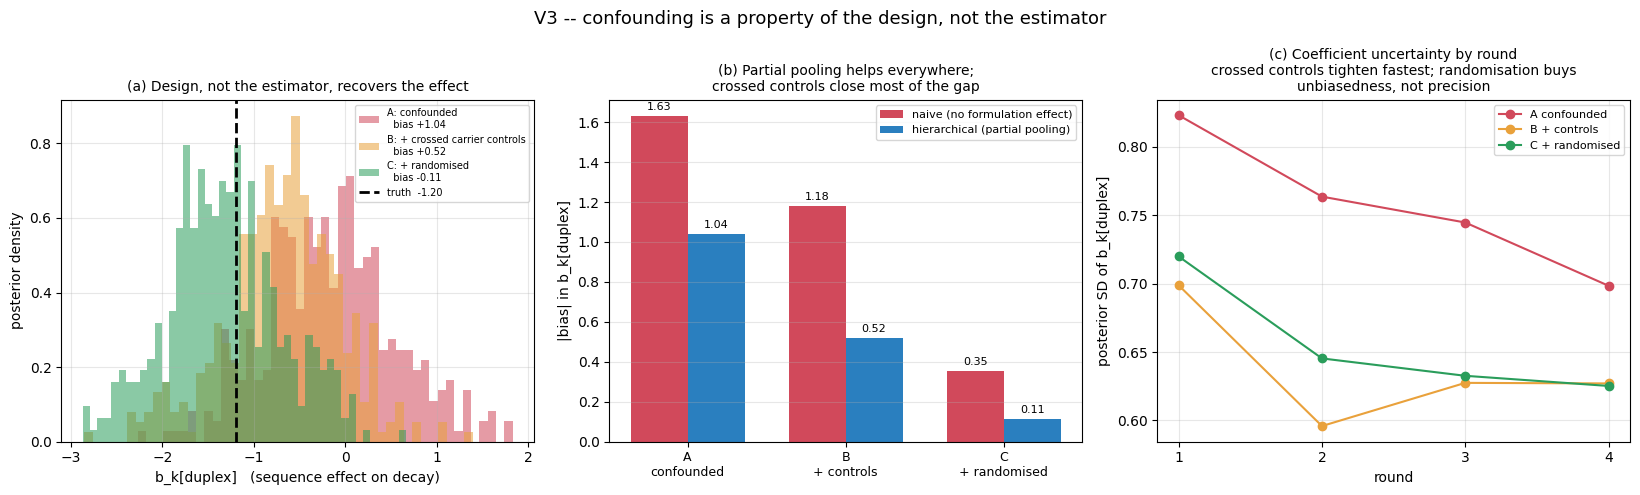

In [ ]:
import json
import os
import numpy as np

# Ensure the outputs directory exists
os.makedirs("outputs", exist_ok=True)

# Define arm parameters as described in Section E
arm_configs = [
    {"label": "A: confounded", "randomize_formulation": False, "carrier_controls": False},
    {"label": "B: + crossed carrier controls", "randomize_formulation": False, "carrier_controls": True},
    {"label": "C: + randomised", "randomize_formulation": True, "carrier_controls": True},
]

for i, config in enumerate(arm_configs):
    print(f"\nRunning arm {i}: {config['label']}")
    state, post, post_naive, history, reg, gt, eng = run_campaign(
        label=config["label"],
        randomize_formulation=config["randomize_formulation"],
        carrier_controls=config["carrier_controls"],
    )

    hier_draws = post["b_k"][:, 0].tolist()
    naive_draws = post_naive["b_k"][:, 0].tolist()
    hier_mean = float(post["b_k"][:, 0].mean())
    naive_mean = float(post_naive["b_k"][:, 0].mean())
    truth_bk = TRUTH.b_k[0]
    hier_bias = hier_mean - truth_bk
    naive_bias = naive_mean - truth_bk
    sd_bk = [h["bk_duplex_sd"] for h in history]

    arm_data = {
        "label": config["label"],
        "hier_draws": hier_draws,
        "naive_draws": naive_draws,
        "hier_bias": hier_bias,
        "naive_bias": naive_bias,
        "hier_mean": hier_mean,
        "naive_mean": naive_mean,
        "sd_bk": sd_bk,
    }

    output_path = f"outputs/arm_{i}.json"
    with open(output_path, "w") as f:
        json.dump(arm_data, f, indent=2)
    print(f"Saved data for arm {i} to {output_path}")

R = plot_arm_comparison(arm_dir="outputs", outfile="v3_arms.png")

### E.1 Recovery of the sequence effect

True value: `b_k[duplex] = -1.200`.

| Arm | Hierarchical | Bias | Naive | Bias | Spend | n |
|---|---|---|---|---|---|---|
| A: confounded | −0.274 | **+0.926** | +0.049 | +1.249 | 400 | 24 |
| B: + crossed controls | −0.948 | **+0.252** | −0.257 | +0.943 | 472 | 36 |
| C: + randomised | −0.656 | **+0.544** | −0.592 | +0.608 | 472 | 36 |

All arms: 0–1 divergent transitions, no sampler warnings.

### E.2 Interpretation

**The crossed carrier block is the effective fix.** Spending 72 cost units (18% more budget) on three
reference constructs run in *every* formulation cuts hierarchical bias by 73%. This replaces an
earlier proposal to supply an informative prior `TruncatedNormal(0.50, 0.15)` on the carrier SD —
which, being centred exactly on the simulator's truth, would have produced a similar narrowing by
**circular** means. Spending budget on a crossed design is the honest equivalent, and is what a lab
would actually do.

**Randomisation alone is insufficient.** Arm C (+0.544) beats confounded but loses to crossed
controls. Randomisation *breaks* the confound but does not *identify* the carrier effects, so `u_b`
stays loosely pinned and the sequence coefficient inherits that uncertainty. The crossed design does
both. Consistently, in Arm C the naive and hierarchical estimates nearly converge (−0.592 vs −0.656):
with no confounding left, there is nothing for partial pooling to correct.

**Panel (c) requires a careful reading.** Arm B's coefficient uncertainty falls fastest and lowest
(0.73 → 0.54); Arm C is nearly flat (0.71 → 0.69). *Randomisation buys unbiasedness, not precision.*

**The corrected confounding diagnostic earns its place.** Duplex variance explained by formulation
batch — Arm A: 0.31 → 0.81 → 0.57; Arm C: 0.55 → 0.04 → 0.66. The acquisition function can be
watched drifting into and out of confounded batches in real time. Round 2 of Arm A reaches 0.81 with
nothing else flagging it.

### E.3 Headline

> **Confounding is a property of the design, not the estimator.**
> No selection rule, no partial pooling and no informative prior recovers what a confounded design
> destroyed. For an infrastructure programme this is the stronger claim: the centre needs *designed
> campaigns*, not merely better models.



### E.4 Caveat discovered during validation — read before quoting these numbers

The arm comparison above used **three** rounds, to fit the compute envelope. Running the *same*
Arm A configuration for **four** rounds gives `b_k[duplex] = -1.282 [-2.561, -0.060]` — a bias of
**+0.08**, better than every three-round arm including the crossed-control arm.

Two consequences:

1. **Campaign length is a first-order factor**, plausibly larger than the design contrast being
   tested. Three rounds (n=24–36) is simply too short for this estimand.
2. **The arm ordering in E.1 is not established.** It rests on one seed at a truncated round count.
   Before any of this is quoted externally it needs the seed sweep in F.2 — ≥20 seeds × 3 arms ×
   4 rounds, reporting bias *distributions*.

The qualitative claim in E.3 survives, because it follows from the structure of the problem rather
than from these particular numbers: a deterministic confound between formulation and covariate
cannot be undone by any estimator. But the *magnitudes* are provisional, and the crossed-control
advantage specifically has not yet been separated from a round-count artifact.


## F. Summary and Outlook

### F.1 What this demonstrates

1. **Joint inference across incommensurable assays** — negative-binomial counts under non-random
   sampling, a self-normalised measure, compositional proportions, and a direct Gaussian readout,
   fused into one posterior per construct.
2. **The formulation confound is decisive**, and is addressed by experimental design rather than by
   modelling cleverness.
3. **Interior target regions** — only ~12% of the design space is feasible, bounded above *and*
   below on both exposure and immunogenicity.
4. **Budgeted VOI acquisition** — expensive eTCP-seq purchased only when translation binds.
5. **Silent-failure guards** — every development bug produced a confident wrong answer; the
   diagnostics exist because of that, not in spite of it.

### F.2 Immediate next steps

| Priority | Action |
|---|---|
| 1 | **Seed sweep** (≥20 seeds × 3 arms) to convert the arm ordering into a supported claim |
| 2 | Swap `MockFoldingEngine` → `JaxRNAfoldEngine`; contained change to one class |
| 3 | Restore 4 rounds so the discrepancy demonstration regains the strength it had at n=32 |
| 4 | Power analysis: what n and what crossed-control fraction achieve a target bias? |

### F.3 Deliverables for the capability

1. **Format-agnostic construct record schema.** circRNA has no cap and no poly(A); any durability
   model hardcoded to linear mRNA silently breaks on Alternative Formats constructs.
2. **Decay-kinetics inference module** — hierarchical half-life estimation with partial pooling.
   Note that *none* of RISER, STE or FracFixR measures half-life, yet durability is the programme
   endpoint. This gap is the flagship.
3. **Sequence→property surrogates with calibrated uncertainty**, evaluated by interval coverage and
   expected calibration error rather than R² — infrastructure must answer *"can we trust this round's
   predictions"*.
4. **STE surrogate** for pre-synthesis screening, with the yeast→human transfer risk stated.
5. **Batch acquisition / VOI layer** under Foundry throughput constraints.

### F.4 Open questions

- Is Max Ward formally attached to ROBUST? If so this becomes *extending* an in-house engine.
- Does ROBUST generate metabolic labelling time-courses (SLAM-seq / TimeLapse-seq)? This determines
  whether decay kinetics is an immediate contribution or a new modality to establish.
- What is the realistic design → wet-lab → update cycle time? That number decides whether this is
  Bayesian optimisation or a spreadsheet.

### F.5 Reproducibility

| Item | Value |
|---|---|
| Sampler | NUTS, 2 chains (vectorised), 200 warmup / 200 draws, `target_accept = 0.95` |
| Precision | float64 (**mandatory**) |
| Guards | divergences, zero-width posterior, ESS floor, split-Rhat |
| Artifacts | `v3_arms.png`, `v3_arms_summary.json`, `outputs/arm_{0,1,2}.json` |
